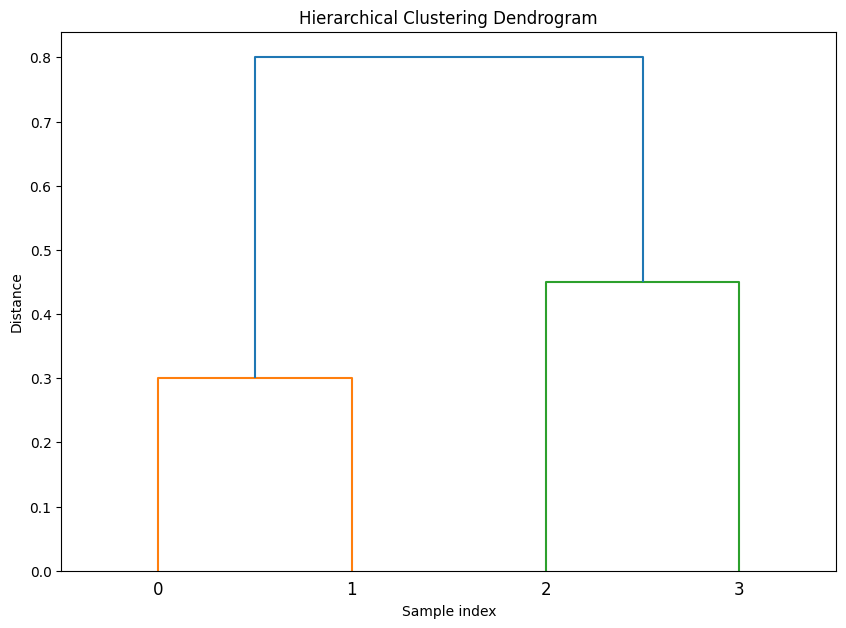

In [1]:
############### Question 2 #################



## a ##


import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

m = np.array([[0, 0.3, 0.4, 0.7],
              [0.3, 0, 0.5, 0.8],
              [0.4, 0.5, 0, 0.45],
              [0.7, 0.8, 0.45, 0]])

# Performing hierarchical clustering
c1 = sch.linkage(sch.distance.squareform(m), method='complete')

# Plotting the dendrogram
plt.figure(figsize=(10, 7))
sch.dendrogram(c1)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

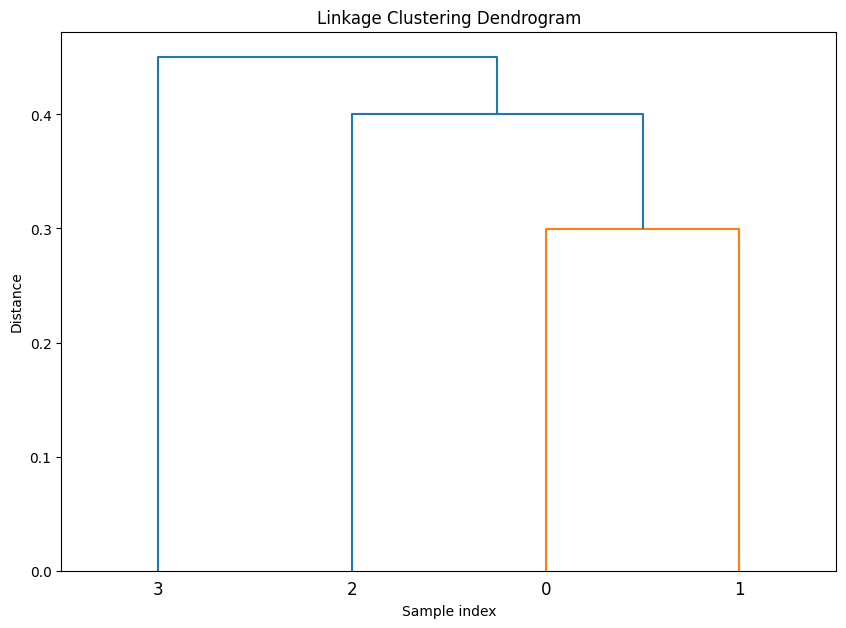

In [2]:
### b ###
c2 = sch.linkage(sch.distance.squareform(m), method='single')

# Plotting the dendrogram
plt.figure(figsize=(10, 7))
sch.dendrogram(c2)
plt.title("Linkage Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

In [3]:
#### c ####

# Forming two clusters
clusters = sch.fcluster(c1, t=2, criterion='maxclust')

# Identifying observations in each cluster
cluster_1 = np.where(clusters == 1)[0]
cluster_2 = np.where(clusters == 2)[0]

cluster_1, cluster_2

(array([0, 1], dtype=int64), array([2, 3], dtype=int64))

In [4]:
#### d ####

# Forming two clusters
clusters = sch.fcluster(c2, t=2, criterion='maxclust')

# Identifying observations in each cluster
cluster_1 = np.where(clusters == 1)[0]
cluster_2 = np.where(clusters == 2)[0]

cluster_1, cluster_2

(array([0, 1, 2], dtype=int64), array([3], dtype=int64))

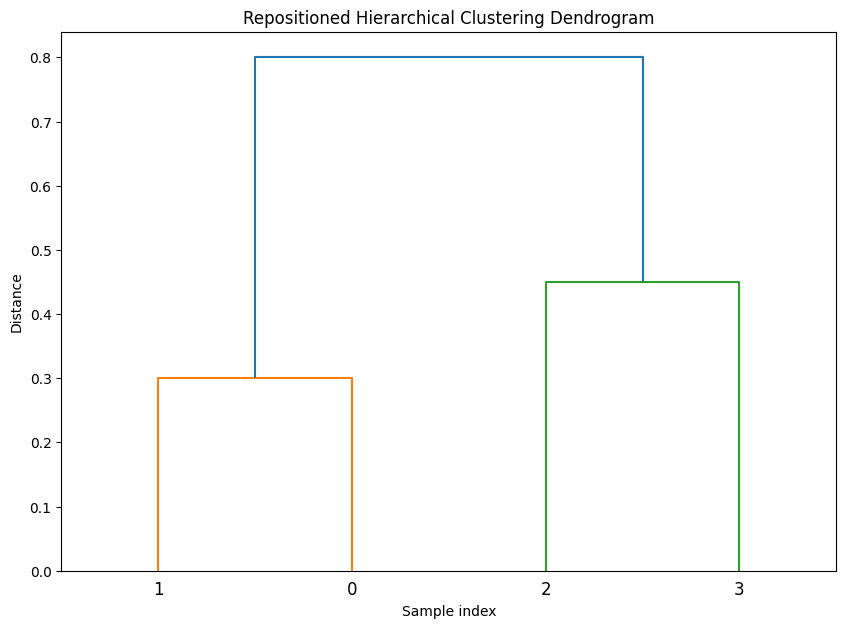

In [5]:
### e ###

# Assuming m is already defined as before
c1 = sch.linkage(sch.distance.squareform(m), method='complete')

# Plotting the dendrogram with reordered leaves
plt.figure(figsize=(10, 7))
sch.dendrogram(c1, labels=[1, 0, 2, 3])
plt.title("Repositioned Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()


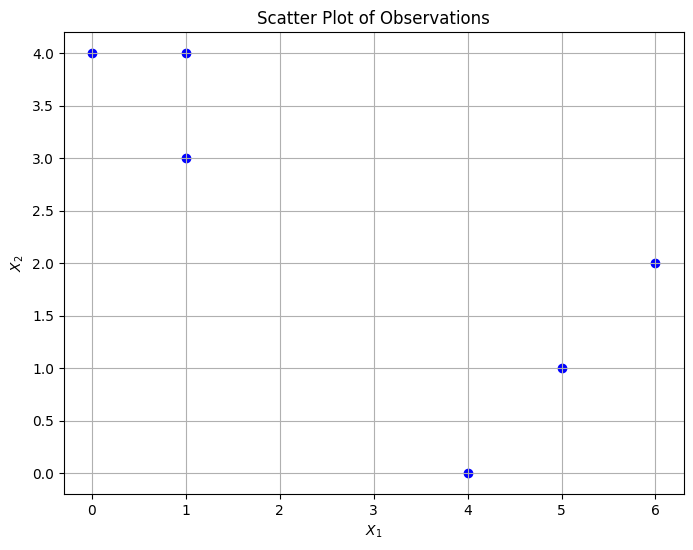

In [6]:
################ Problem 3 #################

### a ###

import matplotlib.pyplot as plt

# Data points
x1 = [1, 1, 0, 5, 6, 4]
x2 = [4, 3, 4, 1, 2, 0]

# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x1, x2, color='blue')
plt.title("Scatter Plot of Observations")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.grid(True)
plt.show()


In [7]:
### b ###

# Setting the seed for reproducibility
np.random.seed(42)

# Observations
observations = np.array([[1, 4], [1, 3], [0, 4], [5, 1], [6, 2], [4, 0]])

# Randomly assigning cluster labels
cluster_labels = np.random.choice([1, 2], size=len(observations), replace=True)

# Combine observations with their cluster labels
cluster_assignments = list(zip(observations, cluster_labels))
print(cluster_assignments)


[(array([1, 4]), 1), (array([1, 3]), 2), (array([0, 4]), 1), (array([5, 1]), 1), (array([6, 2]), 1), (array([4, 0]), 2)]


In [8]:
### c ###


# Initialize an empty list to store centroids
centroids = []

# Compute the centroid for each cluster
for i in [1, 2]:
    cluster_points = observations[cluster_labels == i]
    centroid = np.mean(cluster_points, axis=0)
    centroids.append(centroid)

print(centroids)


[array([3.  , 2.75]), array([2.5, 1.5])]


In [9]:
### d ###

# Calculate Euclidean distances and assign new cluster labels
new_cluster_labels = []
for obs in observations:
    distances = [np.sqrt(np.sum((obs - centroid)**2)) for centroid in centroids]
    new_cluster_labels.append(np.argmin(distances) + 1)  # Adding 1 because cluster labels are 1 and 2

print(new_cluster_labels)


[1, 1, 1, 2, 1, 2]


In [10]:
### e ###
observations = np.array([[1, 4], [1, 3], [0, 4], [5, 1], [6, 2], [4, 0]])
np.random.seed(42)
cluster_labels = np.random.choice([1, 2], size=len(observations), replace=True)

# print(centroids, cluster_labels)

# Function to compute centroids
def compute_centroids(observations, labels):
    return [np.mean(observations[labels == i], axis=0) for i in [1, 2]]

# Function to assign new cluster labels based on centroids
def assign_clusters(observations, centroids):
    new_labels = []
    for obs in observations:
        distances = [np.sqrt(np.sum((obs - centroid) ** 2)) for centroid in centroids]
#        print(distances)
        new_labels.append(np.argmin(distances) + 1)
#    print("")
    return np.array(new_labels)

# Repeating steps (c) and (d) until the cluster assignments stop changing
while True:
    centroids = compute_centroids(observations, cluster_labels)
    new_cluster_labels = assign_clusters(observations, centroids)

#    print(centroids, cluster_labels, new_cluster_labels)

    # Check if the cluster labels have changed
    if np.array_equal(new_cluster_labels, cluster_labels):
        break
    else:
        cluster_labels = new_cluster_labels


final_clusters = cluster_labels

# Final cluster assignments and centroids
final_clusters, centroids


(array([1, 1, 1, 2, 2, 2], dtype=int64),
 [array([0.66666667, 3.66666667]), array([5., 1.])])

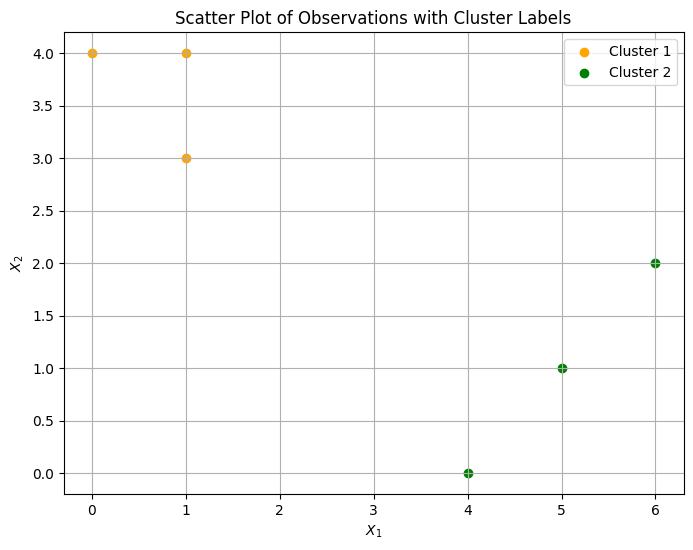

In [11]:
### f ###

# Define colors for each cluster
colors = ['orange', 'green']

# Creating the scatter plot
plt.figure(figsize=(8, 6))
for i in range(1, 3):  # Clusters are labeled 1 and 2
    cluster_points = observations[np.array(final_clusters) == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i-1], label=f'Cluster {i}')

plt.title("Scatter Plot of Observations with Cluster Labels")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
'!pip install ISLP'

'!pip install ISLP'

In [16]:
############ Problem 8 #########



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data



USArrests = get_rdataset('USArrests').data

USArrests.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [17]:
# Sample data to simulate 'USArrests' dataset
np.random.seed(0)
sample_data = np.random.rand(50, 4)  # 50 samples, 4 features

sample_data = USArrests

# Standardize the dataset
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sample_data)

# Part a: Using the sdev output of the prcomp() function
pca_a = PCA()
pca_a.fit(scaled_data)
pve_a = pca_a.explained_variance_ratio_

pve_a

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

In [18]:
# Part b: Applying Equation 12.10 directly
pca_b = PCA()
X_transformed = pca_b.fit_transform(scaled_data)
pve_b = np.sum(X_transformed**2, axis=0) / np.sum(scaled_data**2)

pve_b

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

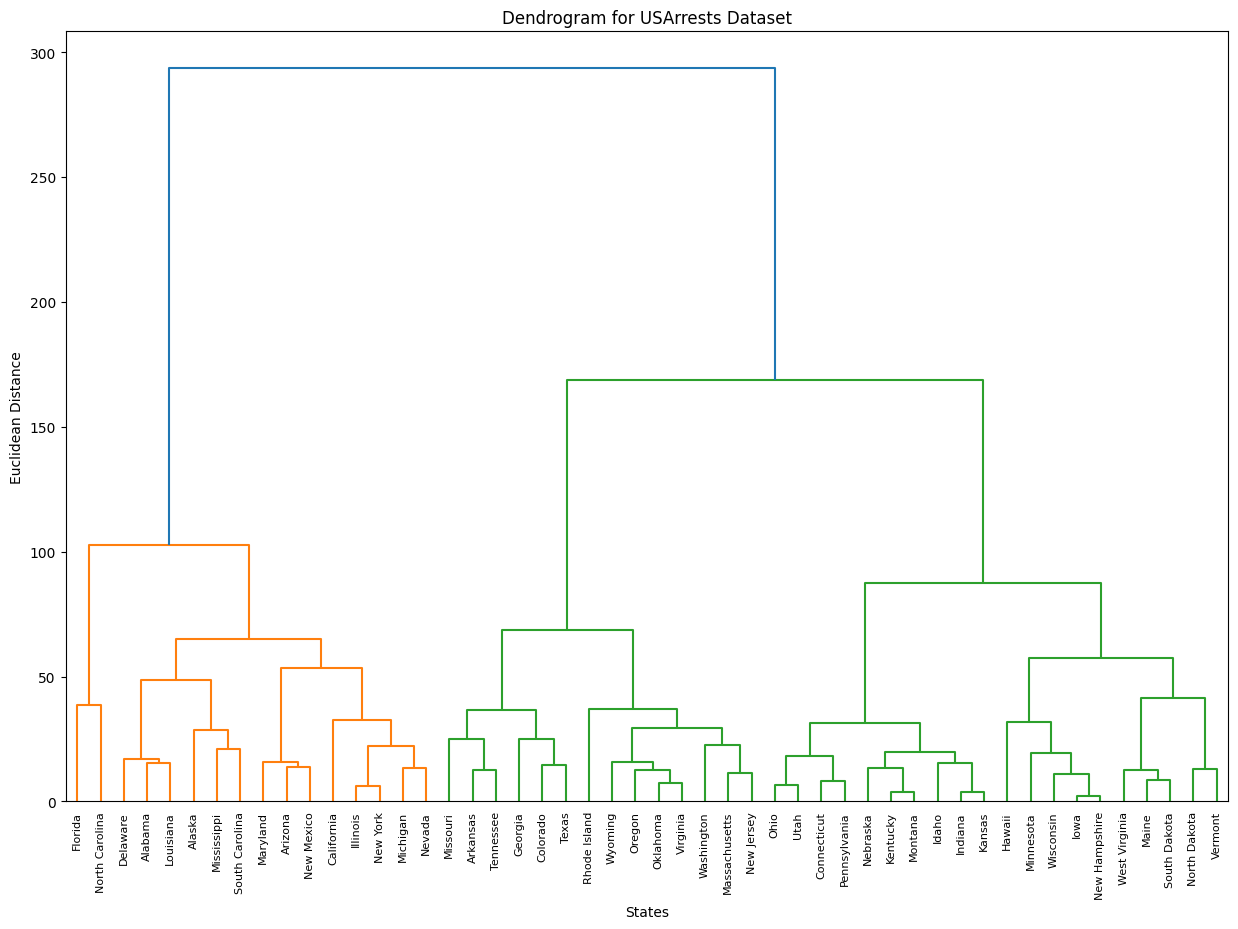

In [44]:
######### Problem 9 ############


import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.datasets import get_rdataset


# a. Hierarchical clustering with complete linkage and Euclidean distance
np.random.seed(42)
hc_uploaded = linkage(USArrests, method='complete')


plt.figure(figsize=(15, 10))
dendrogram(hc_uploaded, labels=sample_data.index, leaf_rotation=90)
plt.title('Dendrogram for USArrests Dataset')
plt.xlabel('States')
plt.ylabel('Euclidean Distance')
plt.show()



In [20]:
# b. Cutting the dendrogram to form three clusters
clusters_uploaded = fcluster(hc_uploaded, 3, criterion='maxclust')
cluster_dict_uploaded = {i: USArrests.index[clusters_uploaded == i].tolist() for i in range(1, 4)}

cluster_dict_uploaded

{1: ['Alabama',
  'Alaska',
  'Arizona',
  'California',
  'Delaware',
  'Florida',
  'Illinois',
  'Louisiana',
  'Maryland',
  'Michigan',
  'Mississippi',
  'Nevada',
  'New Mexico',
  'New York',
  'North Carolina',
  'South Carolina'],
 2: ['Arkansas',
  'Colorado',
  'Georgia',
  'Massachusetts',
  'Missouri',
  'New Jersey',
  'Oklahoma',
  'Oregon',
  'Rhode Island',
  'Tennessee',
  'Texas',
  'Virginia',
  'Washington',
  'Wyoming'],
 3: ['Connecticut',
  'Hawaii',
  'Idaho',
  'Indiana',
  'Iowa',
  'Kansas',
  'Kentucky',
  'Maine',
  'Minnesota',
  'Montana',
  'Nebraska',
  'New Hampshire',
  'North Dakota',
  'Ohio',
  'Pennsylvania',
  'South Dakota',
  'Utah',
  'Vermont',
  'West Virginia',
  'Wisconsin']}

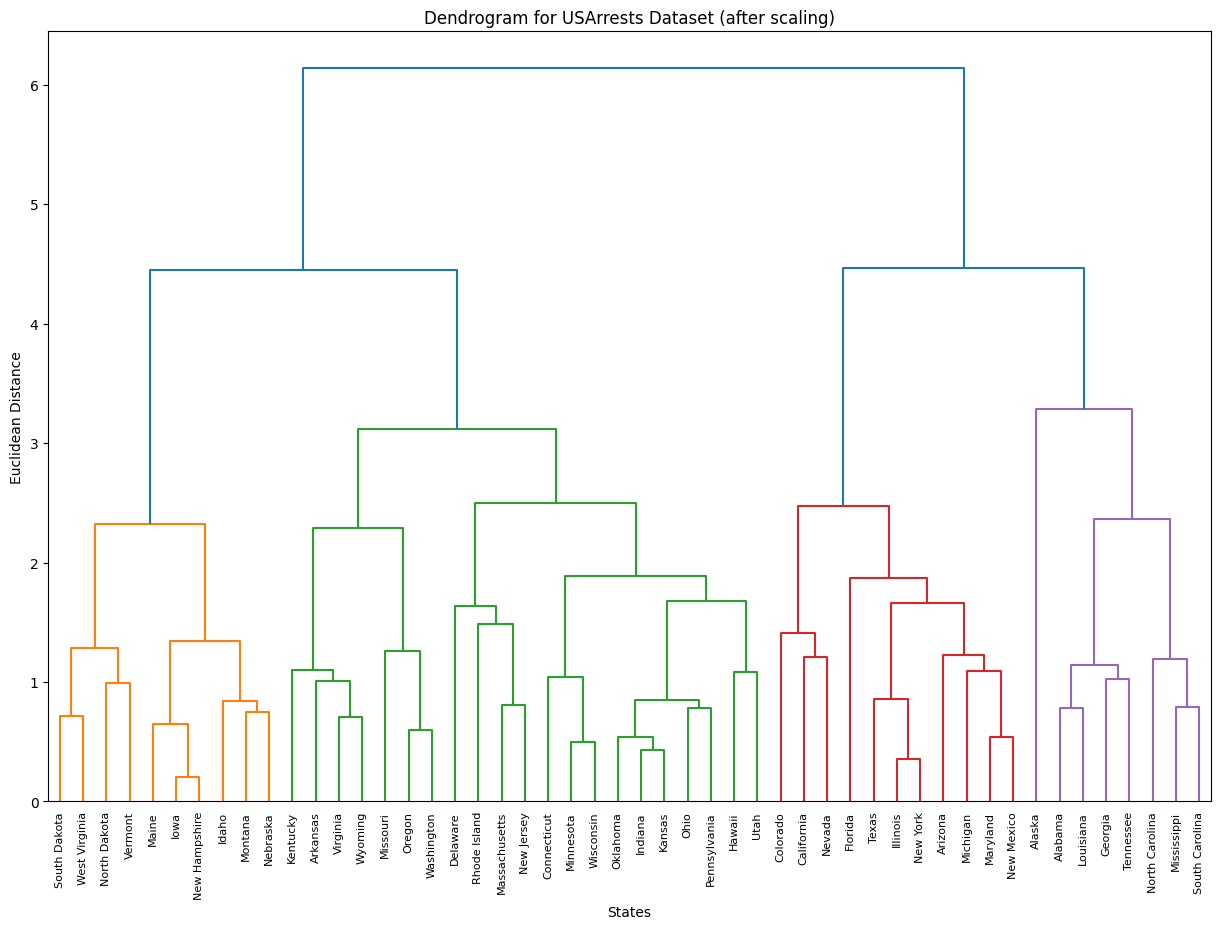

In [45]:
# c. Hierarchical clustering after scaling the variables
scaler = StandardScaler()
USArrests_scaled_uploaded = scaler.fit_transform(USArrests)
hc_scaled_uploaded = linkage(USArrests_scaled_uploaded, method='complete')

plt.figure(figsize=(15, 10))
dendrogram(hc_scaled_uploaded, labels=sample_data.index, leaf_rotation=90)
plt.title('Dendrogram for USArrests Dataset (after scaling)')
plt.xlabel('States')
plt.ylabel('Euclidean Distance')
plt.show()

In [22]:

# d. Cutting the scaled dendrogram to form three clusters
clusters_scaled_uploaded = fcluster(hc_scaled_uploaded, 3, criterion='maxclust')
cluster_scaled_dict_uploaded = {i: USArrests.index[clusters_scaled_uploaded == i].tolist() for i in range(1, 4)}

cluster_scaled_dict_uploaded

{1: ['Arkansas',
  'Connecticut',
  'Delaware',
  'Hawaii',
  'Idaho',
  'Indiana',
  'Iowa',
  'Kansas',
  'Kentucky',
  'Maine',
  'Massachusetts',
  'Minnesota',
  'Missouri',
  'Montana',
  'Nebraska',
  'New Hampshire',
  'New Jersey',
  'North Dakota',
  'Ohio',
  'Oklahoma',
  'Oregon',
  'Pennsylvania',
  'Rhode Island',
  'South Dakota',
  'Utah',
  'Vermont',
  'Virginia',
  'Washington',
  'West Virginia',
  'Wisconsin',
  'Wyoming'],
 2: ['Arizona',
  'California',
  'Colorado',
  'Florida',
  'Illinois',
  'Maryland',
  'Michigan',
  'Nevada',
  'New Mexico',
  'New York',
  'Texas'],
 3: ['Alabama',
  'Alaska',
  'Georgia',
  'Louisiana',
  'Mississippi',
  'North Carolina',
  'South Carolina',
  'Tennessee']}

In [23]:
######### Problem 13 ##########


import pandas as pd

# Load the data
file_path = 'Ch12Ex13.csv'
data = pd.read_csv(file_path, header=None)

# Assign column names as specified
data.columns = [f'H{i+1}' if i < 20 else f'D{i-19}' for i in range(0, 40)]

data.head()  # Display the first few rows to verify the loading and naming process


,H1,H2,H3,H4,H5,H6,H7,H8,H9,H10,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,-0.961933,0.441803,-0.975005,1.417504,0.818815,0.316294,-0.024967,-0.063966,0.031497,-0.350311,...,-0.509591,-0.216725,-0.055506,-0.484449,-0.521581,1.949135,1.324335,0.468147,1.061100,1.655970
1,-0.292526,-1.139267,0.195837,-1.281121,-0.251439,2.511997,-0.922206,0.059543,-1.409645,-0.656712,...,1.700708,0.007290,0.099062,0.563853,-0.257275,-0.581781,-0.169887,-0.542304,0.312939,-1.284377
2,0.258788,-0.972845,0.588486,-0.800258,-1.820398,-2.058924,-0.064764,1.592124,-0.173117,-0.121087,...,-0.615472,0.009999,0.945810,-0.318521,-0.117889,0.621366,-0.070764,0.401682,-0.016227,-0.526553
3,-1.152132,-2.213168,-0.861525,0.630925,0.951772,-1.165724,-0.391559,1.063619,-0.350009,-1.489058,...,-0.284277,0.198946,-0.091833,0.349628,-0.298910,1.513696,0.671185,0.010855,-1.043689,1.625275
4,0.195783,0.593306,0.282992,0.247147,1.978668,-0.871018,-0.989715,-1.032253,-1.109654,-0.385142,...,-0.692998,-0.845707,-0.177497,-0.166491,1.483155,-1.687946,-0.141430,0.200778,-0.675942,2.220611


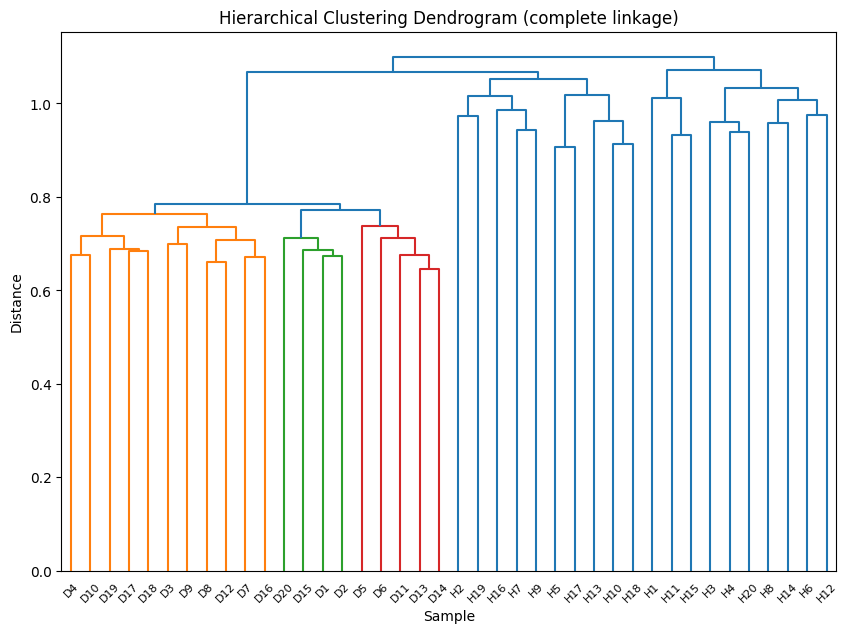

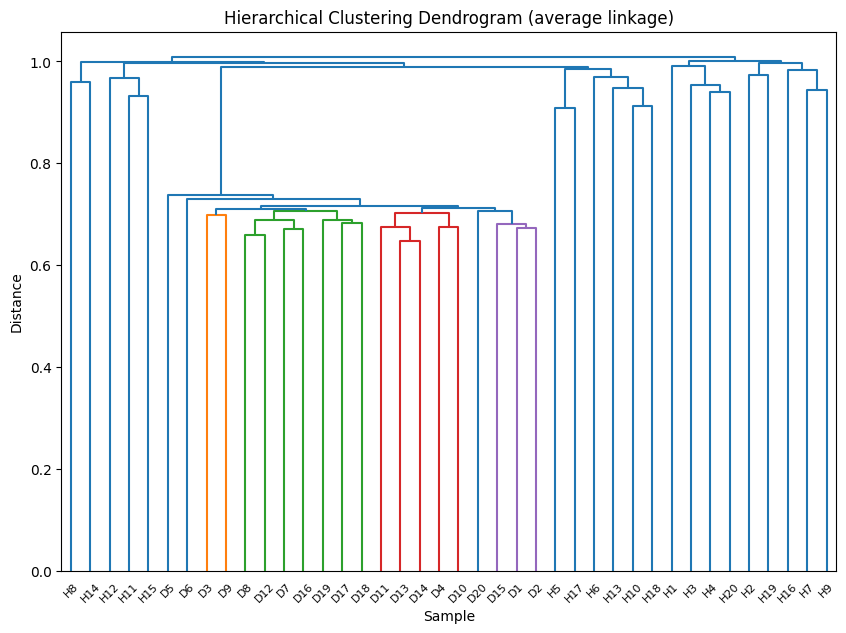

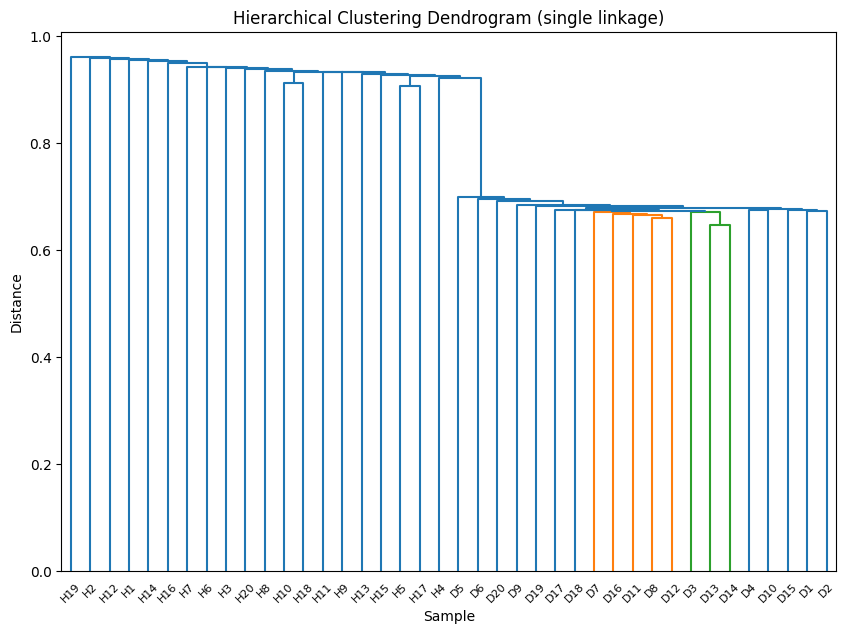

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import numpy as np

# Define a function to perform hierarchical clustering and plot the dendrogram
def plot_hierarchical_clustering(data, method):
    # Calculate the correlation-based distance
    correlation_distance = 1 - np.corrcoef(data.T)

    # Convert full distance matrix to condensed form
    condensed_dist_matrix = squareform(correlation_distance, checks=False)

    # Then use this condensed matrix in the linkage function
    hc = linkage(condensed_dist_matrix, method=method)


    # Plot the dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(hc, labels=data.columns)
    plt.title(f"Hierarchical Clustering Dendrogram ({method} linkage)")
    plt.xlabel("Sample")
    plt.ylabel("Distance")
    plt.show()

# Apply hierarchical clustering using different linkage methods
linkage_methods = ["complete", "average", "single"]
for method in linkage_methods:
    plot_hierarchical_clustering(data, method)


In [36]:
from scipy.stats import ttest_ind

# Create a label vector for the two groups
labels = ['Healthy']*20 + ['Diseased']*20


# Calculate p-values for each gene
p_values = []
for row in data.iterrows():
    gene_data = row[1]
    t_stat, p_val = ttest_ind(gene_data[:20], gene_data[20:])  # Comparing healthy vs diseased
    # print(gene_data[:20], gene_data[20:])
    p_values.append(p_val)

# Adjust p-values for multiple testing (False Discovery Rate)
adjusted_p_values = pd.Series(p_values).apply(lambda p: min(p * len(p_values), 1.0))

# Find genes with significant difference (threshold: adjusted p-value < 0.05)
significant_genes = adjusted_p_values < 0.05

# Display the indices of the significant genes
significant_gene_indices = significant_genes[significant_genes].index + 1  # Adding 1 to match the gene numbering in the dataset
significant_gene_indices.tolist()


[11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 501,
 502,
 503,
 504,
 505,
 506,
 507,
 508,
 509,
 511,
 512,
 513,
 514,
 515,
 516,
 517,
 519,
 520,
 521,
 522,
 523,
 524,
 525,
 526,
 527,
 528,
 529,
 530,
 531,
 532,
 533,
 534,
 535,
 536,
 537,
 538,
 539,
 540,
 541,
 542,
 543,
 544,
 545,
 546,
 547,
 548,
 549,
 550,
 551,
 552,
 553,
 554,
 555,
 556,
 557,
 558,
 559,
 560,
 561,
 562,
 563,
 564,
 565,
 566,
 567,
 568,
 569,
 570,
 571,
 572,
 574,
 575,
 576,
 577,
 578,
 579,
 580,
 581,
 582,
 583,
 584,
 586,
 587,
 588,
 589,
 590,
 591,
 592,
 593,
 595,
 596,
 597,
 598,
 599,
 600]

In [37]:
########## Chapter 13 #############

In [40]:
########### Problem 4 #############


import numpy as np

# Given p-values
pvals = np.array([0.0011, 0.031, 0.017, 0.32, 0.11, 0.90, 0.07, 0.006, 0.004, 0.0009])
hypotheses = ["H01", "H02", "H03", "H04", "H05", "H06", "H07", "H08", "H09", "H10"]

# a. Control the Type I error for each null hypothesis at level α = 0.05
rejected_a = [h for h, p in zip(hypotheses, pvals) if p < 0.05]

# b. Control the FWER at level α = 0.05
alpha_fwer = 0.05 / 10
rejected_b = [h for h, p in zip(hypotheses, pvals) if p < alpha_fwer]

# c. Control the FDR at level q = 0.05
from statsmodels.stats.multitest import multipletests
rejected_c, _, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')
rejected_hypotheses_c = [h for h, rej in zip(hypotheses, rejected_c) if rej]

rejected_a, rejected_b, rejected_hypotheses_c



(['H01', 'H02', 'H03', 'H08', 'H09', 'H10'],
 ['H01', 'H09', 'H10'],
 ['H01', 'H03', 'H08', 'H09', 'H10'])

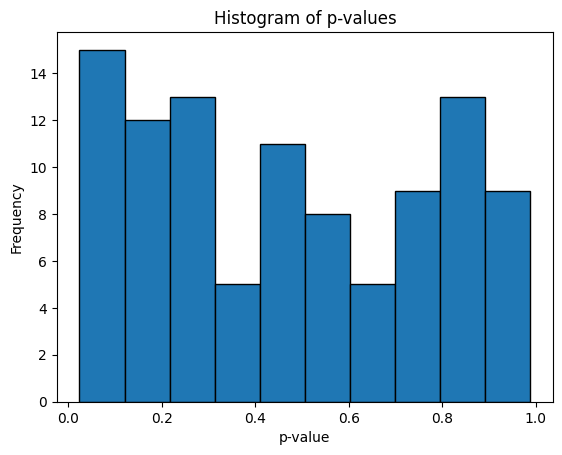

(3, 0, 0)

In [46]:
#################### Problem 8 ####################

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

# Set seed for reproducibility
np.random.seed(1)

# Simulate the data
n = 20
m = 100
X = np.random.normal(0, 1, (n, m))

# Perform one-sample t-tests
pvals = np.array([stats.ttest_1samp(X[:, j], 0)[1] for j in range(m)])

# Plot histogram of p-values
plt.hist(pvals, bins=10, edgecolor='black')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Histogram of p-values')
plt.show()

# Type I error control at level α = 0.05
type1_errors = np.sum(pvals < 0.05)

# Control the FWER at level 0.05
fwer_errors = np.sum(pvals < 0.05 / m)

# Control the FDR at level 0.05
fdr_results = multipletests(pvals, alpha=0.05, method='fdr_bh')
fdr_errors = np.sum(fdr_results[0])

# Results for Type I error, FWER, and FDR control
type1_errors, fwer_errors, fdr_errors


In [47]:
# Cherry-picking the 10 best performing fund managers
# In this case, "best" is interpreted as having the highest total returns over the period
best_performers = np.argsort(np.sum(X, axis=0))[-10:]
pvals_best = pvals[best_performers]

# FWER control for the 10 cherry-picked fund managers (Bonferroni correction)
fwer_best = np.sum(pvals_best < 0.05 / 10)

# FDR control for the 10 cherry-picked fund managers
fdr_best_results = multipletests(pvals_best, alpha=0.05, method='fdr_bh')
fdr_best = np.sum(fdr_best_results[0])

# Results for FWER and FDR control for cherry-picked managers
fwer_best, fdr_best


(0, 0)